# Per-Type Contribution Ladder

Expands 5A from `analysis.ipynb` by breaking the pipeline contribution ladder down by caption type and cross-type combinations. Both **T2I** (text→image) and **I2T** (image→text) sides are shown.

| Section | Subsets |
|---|---|
| 1 | Single types: caption, description, impression, aesthetic |
| 2 | 2-type combos (6) |
| 3 | 3-type combos (4) |
| 4 | Summary heatmap — R@1 across all 15 subsets |

Pipeline steps (same as 5A + subset-specific condition):
CLIP → +other_proj → +zero cond → +avg cond → **+subset cond** → +predicted → +oracle

In [1]:
EXPERIMENT_DIR = (
    "/project/CoSiR/res/CoSiR_Experiment/impressions/20260602_054458_sweep_73jsta4o"
)
EPOCH      = None   # None → latest
DEVICE     = "cuda"
TYPE_NAMES  = ["caption", "description", "impression", "aesthetic"]
TYPE_COLORS = ["#888888", "#2196F3", "#FF9800", "#4CAF50"]

In [2]:
import os, glob, warnings
from itertools import combinations
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")

import importlib.util as _ilu
def _load_file(name, path):
    spec = _ilu.spec_from_file_location(name, path)
    mod  = _ilu.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

_proj = os.path.normpath(os.path.join(os.path.abspath(""), "../../.."))
_cm   = _load_file("combiner", os.path.join(_proj, "src/model/combiner.py"))
Combiner_new       = _cm.Combiner_new
OtherProjMLP       = _cm.OtherProjMLP
ConditionPredictor = _load_file(
    "condition_predictor",
    os.path.join(_proj, "src/model/condition_predictor.py")
).ConditionPredictor
print("Modules loaded")

Modules loaded


In [3]:
cond_dir = os.path.join(EXPERIMENT_DIR, "condition_viz")
ca_dir   = os.path.join(EXPERIMENT_DIR, "condition_analysis")

fixed = torch.load(os.path.join(cond_dir, "fixed_data.pt"), map_location="cpu", weights_only=False)
all_img_emb    = fixed["all_img_emb"]         # [N_img, 512]
all_txt_emb    = fixed["all_txt_emb"]         # [N_txt, 512]
img2txt        = fixed["image_to_text_map"]   # [N_img, cpi]
txt2img        = fixed["text_to_image_map"]   # [N_txt]
cpi            = fixed["captions_per_image"]
test_cap_types = fixed["test_caption_types"]  # [N_txt] type index per text
n_img, n_txt   = all_img_emb.shape[0], all_txt_emb.shape[0]
print(f"Test: {n_img} images × {cpi} caps = {n_txt} texts")
print("Type counts:", {TYPE_NAMES[t]: (test_cap_types == t).sum().item() for t in range(4)})

epoch_files = sorted(glob.glob(os.path.join(cond_dir, "epoch_*.pt")))
snap_path   = epoch_files[-1] if EPOCH is None else os.path.join(cond_dir, f"epoch_{EPOCH:04d}.pt")
snap        = torch.load(snap_path, map_location="cpu", weights_only=False)
epoch          = snap["epoch"]
label_emb_all  = snap["label_embeddings_all"]
representatives = snap["representatives"]     # [K, D_cond]
combine_side    = snap.get("combine_side", "img")
train_types     = snap.get("train_sample_types")
K               = len(representatives)
label_dim       = representatives.shape[1]
print(f"Epoch {epoch} | K={K} | label_dim={label_dim} | combine_side={combine_side}")

HAS_CA = False
ca_files = sorted(glob.glob(os.path.join(ca_dir, "epoch_*.pt"))) if os.path.exists(ca_dir) else []
if ca_files:
    ca_path = ca_files[-1] if EPOCH is None else os.path.join(ca_dir, f"epoch_{EPOCH:04d}.pt")
    ca = torch.load(ca_path, map_location="cpu", weights_only=False)
    per_rep_gt_rank = ca["per_rep_gt_rank"]  # [K, N_txt] T2I ranks
    HAS_CA = True
    print(f"CA cache loaded (epoch {ca['epoch']})")

Test: 706 images × 4 caps = 2824 texts
Type counts: {'caption': 706, 'description': 706, 'impression': 706, 'aesthetic': 706}
Epoch 999 | K=30 | label_dim=16 | combine_side=img
CA cache loaded (epoch 999)


In [4]:
dev = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
cfg = snap["combiner_config"]
combiner = Combiner_new(
    clip_feature_dim=cfg["clip_feature_dim"],
    projection_dim=cfg["projection_dim"],
    label_dim=cfg["label_dim"],
    hidden_dim=cfg.get("hidden_dim", cfg["clip_feature_dim"]),
    num_heads=cfg.get("num_heads", 8),
    num_layers=cfg.get("num_layers", 2),
    dropout=cfg.get("dropout", 0.1),
).to(dev).eval()
combiner.load_state_dict(snap["combiner_state_dict"])

_fd     = cfg["clip_feature_dim"]
_op_cfg = snap.get("other_proj_config", {})
if _op_cfg.get("type") == "OtherProjMLP":
    other_proj = OtherProjMLP(
        feature_dim=_fd,
        hidden_dim=_op_cfg.get("hidden_dim", 1024),
        num_blocks=_op_cfg.get("num_blocks", 3),
    )
else:
    other_proj = torch.nn.Linear(_fd, _fd)
    torch.nn.init.eye_(other_proj.weight)
    torch.nn.init.zeros_(other_proj.bias)
if "other_proj_state_dict" in snap:
    other_proj.load_state_dict(snap["other_proj_state_dict"])
other_proj = other_proj.to(dev).eval()

predictor = None
if "predictor_state_dict" in snap:
    pcfg = snap["predictor_config"]
    predictor = ConditionPredictor(
        input_dim=pcfg["input_dim"], hidden_dim=pcfg["hidden_dim"],
        output_dim=pcfg["output_dim"], num_layers=pcfg.get("num_layers", 2),
        dropout=pcfg.get("dropout", 0.1),
    ).to(dev).eval()
    predictor.load_state_dict(snap["predictor_state_dict"])
    print("Predictor loaded")

img_n = F.normalize(all_img_emb, dim=-1)
txt_n = F.normalize(all_txt_emb, dim=-1)
with torch.no_grad():
    if combine_side == "txt":
        other_n = F.normalize(other_proj(all_img_emb.to(dev)), dim=-1).cpu()
    else:
        other_n = F.normalize(other_proj(all_txt_emb.to(dev)), dim=-1).cpu()
print("Models ready")

Predictor loaded
Models ready


In [5]:
combine_emb = all_img_emb if combine_side == "img" else all_txt_emb  # [N_combine, 512]

@torch.no_grad()
def apply_cond(emb, cond, bs=256):
    """Apply single (broadcast) condition to all embeddings."""
    out = []
    for i in range(0, emb.shape[0], bs):
        e = emb[i:i+bs].to(dev)
        c = cond.expand(e.shape[0], -1).to(dev)
        out.append(combiner(e, None, c).cpu())
    return F.normalize(torch.cat(out), dim=-1)

def r_at_k(ranks, k):
    return (ranks < k).float().mean().item() * 100

def comb_t2i(comb_out_n):
    """T2I sims [N_txt, N_img] from combiner output [N_combine, 512]."""
    return (other_n @ comb_out_n.T) if combine_side == "img" else (comb_out_n @ other_n.T)

# ── Conditions ────────────────────────────────────────────────────────────────
type_means   = None
cond_avg_all = None
if train_types is not None:
    type_means   = torch.stack([label_emb_all[train_types == t].mean(0) for t in range(4)])
    cond_avg_all = type_means.mean(0, keepdim=True)

zero_cond = torch.zeros(1, label_dim)
out_zero  = apply_cond(combine_emb, zero_cond)

out_avg  = None
sims_avg = None
if type_means is not None:
    out_avg  = apply_cond(combine_emb, cond_avg_all)
    sims_avg = comb_t2i(out_avg)

# ── Predicted condition ───────────────────────────────────────────────────────
out_pred_n = None
sims_pred  = None
if predictor is not None:
    src_emb = all_img_emb if combine_side == "img" else all_txt_emb
    with torch.no_grad():
        raw_pred = torch.cat([predictor(src_emb[i:i+512].to(dev)).cpu()
                              for i in range(0, src_emb.shape[0], 512)])
    with torch.no_grad():
        pred_out = torch.cat([
            combiner(combine_emb[i:i+256].to(dev), None, raw_pred[i:i+256].to(dev)).cpu()
            for i in range(0, combine_emb.shape[0], 256)])
    out_pred_n = F.normalize(pred_out, dim=-1)
    sims_pred  = comb_t2i(out_pred_n)

# ── Baseline T2I sims ─────────────────────────────────────────────────────────
sims_clip = txt_n @ img_n.T
sims_proj = (other_n @ img_n.T) if combine_side == "img" else (txt_n @ other_n.T)
sims_zero = comb_t2i(out_zero)

# ── Per-rep combiner outputs [K, N_combine, 512] ──────────────────────────────
print("Computing per-rep combiner outputs...")
per_rep_comb_out = torch.stack([
    apply_cond(combine_emb, representatives[k:k+1]) for k in range(K)
])  # [K, N_combine, 512]
print(f"per_rep_comb_out: {per_rep_comb_out.shape}")
print("Precomputation done.")

Computing per-rep combiner outputs...
per_rep_comb_out: torch.Size([30, 706, 512])
Precomputation done.


In [6]:
# Build ordered list of all 15 subsets
all_subsets = []
for t in range(4):
    all_subsets.append((TYPE_NAMES[t], (t,)))
for combo in combinations(range(4), 2):
    all_subsets.append(("+".join(TYPE_NAMES[t] for t in combo), combo))
for combo in combinations(range(4), 3):
    all_subsets.append(("+".join(TYPE_NAMES[t] for t in combo), combo))
all_subsets.append(("all (4 types)", tuple(range(4))))

print(f"Total subsets: {len(all_subsets)}")
for name, types in all_subsets:
    n_q = sum((test_cap_types == t).sum().item() for t in types)
    print(f"  {name:35s}  {len(types)} type(s)  {n_q} texts")

Total subsets: 15
  caption                              1 type(s)  706 texts
  description                          1 type(s)  706 texts
  impression                           1 type(s)  706 texts
  aesthetic                            1 type(s)  706 texts
  caption+description                  2 type(s)  1412 texts
  caption+impression                   2 type(s)  1412 texts
  caption+aesthetic                    2 type(s)  1412 texts
  description+impression               2 type(s)  1412 texts
  description+aesthetic                2 type(s)  1412 texts
  impression+aesthetic                 2 type(s)  1412 texts
  caption+description+impression       3 type(s)  2118 texts
  caption+description+aesthetic        3 type(s)  2118 texts
  caption+impression+aesthetic         3 type(s)  2118 texts
  description+impression+aesthetic     3 type(s)  2118 texts
  all (4 types)                        4 type(s)  2824 texts


In [7]:
STEP_COLORS = {
    "CLIP (raw)":    "#bdbdbd",
    "+ other_proj":  "#9e9e9e",
    "+ zero cond":   "#FFCC80",
    "+ avg cond":    "#FF9800",
    "+ subset cond": "#FF5722",
    "+ predicted":   "#2196F3",
    "+ oracle":      "#4CAF50",
}

def compute_ladders(type_tuple):
    """
    Returns (t2i_ladder, i2t_ladder) for a type subset.
    Each ladder is a list of (step_name, ranks[N], color).
    T2I: text queries of these types → rank N_img images.
    I2T: N_img image queries → rank gallery of texts of these types.
    """
    # ── Indices of texts belonging to this subset ──────────────────────────────
    mask = torch.zeros(n_txt, dtype=torch.bool)
    for t in type_tuple:
        mask |= (test_cap_types == t)
    txt_idx = mask.nonzero(as_tuple=True)[0]  # [N_sub]
    N_sub   = len(txt_idx)

    # ── T2I helpers ────────────────────────────────────────────────────────────
    gt_imgs = txt2img[txt_idx]  # [N_sub] GT image per query text

    def t2i_ranks(sims_full):
        """sims_full [N_txt, N_img] → ranks [N_sub]"""
        s   = sims_full[txt_idx]  # [N_sub, N_img]
        gts = s[torch.arange(N_sub), gt_imgs]
        return (s >= gts.unsqueeze(1)).sum(1).long() - 1

    # ── I2T helpers ────────────────────────────────────────────────────────────
    gal_img = txt2img[txt_idx]  # [N_sub] which image each gallery text belongs to
    # GT mask [N_img, N_sub]: True where gallery text belongs to image i
    gt_mask = (gal_img.unsqueeze(0) == torch.arange(n_img).unsqueeze(1))  # [N_img, N_sub]

    def i2t_ranks_from_sub(sims_sub):
        """sims_sub [N_img, N_sub] → ranks [N_img] (best-GT, supports multi-GT)"""
        masked = sims_sub.clone().float()
        masked[~gt_mask] = float("-inf")
        best_gt = masked.max(dim=1).values  # [N_img]
        return (sims_sub >= best_gt.unsqueeze(1)).sum(1).long() - 1

    def i2t_from_t2i(sims_full):
        """I2T gallery sims from full T2I sims [N_txt, N_img]."""
        return sims_full.T[:, txt_idx]  # [N_img, N_sub]

    def i2t_from_comb(comb_out_n):
        """I2T gallery sims from combiner output [N_combine, 512]."""
        if combine_side == "img":
            return comb_out_n @ other_n[txt_idx].T   # [N_img, N_sub]
        else:
            return other_n @ comb_out_n[txt_idx].T   # [N_img, N_sub]

    # ── Subset-specific mean condition ─────────────────────────────────────────
    out_sub      = None
    sims_sub_t2i = None
    if type_means is not None and len(type_tuple) < 4:
        sub_cond     = type_means[list(type_tuple)].mean(0, keepdim=True)
        out_sub      = apply_cond(combine_emb, sub_cond)
        sims_sub_t2i = comb_t2i(out_sub)

    # ── Oracle I2T (vectorised over K reps) ────────────────────────────────────
    if combine_side == "img":
        gal_e      = other_n[txt_idx]                                     # [N_sub, 512]
        sims_k_i2t = torch.matmul(per_rep_comb_out, gal_e.T)             # [K, N_img, N_sub]
    else:
        gal_c      = per_rep_comb_out[:, txt_idx, :]                      # [K, N_sub, 512]
        sims_k_i2t = torch.matmul(
            other_n.unsqueeze(0), gal_c.transpose(1, 2))                  # [K, N_img, N_sub]

    gt_mask_k = gt_mask.unsqueeze(0).expand(K, -1, -1)  # [K, N_img, N_sub]
    masked_k  = sims_k_i2t.clone().float()
    masked_k[~gt_mask_k] = float("-inf")
    best_gt_k  = masked_k.max(dim=2).values                              # [K, N_img]
    ranks_k    = (sims_k_i2t >= best_gt_k.unsqueeze(2)).sum(2).long() - 1
    oracle_i2t = ranks_k.min(0).values                                   # [N_img]

    # ── Assemble T2I ladder ────────────────────────────────────────────────────
    t2i = [
        ("CLIP (raw)",   t2i_ranks(sims_clip),  STEP_COLORS["CLIP (raw)"]),
        ("+ other_proj", t2i_ranks(sims_proj),  STEP_COLORS["+ other_proj"]),
        ("+ zero cond",  t2i_ranks(sims_zero),  STEP_COLORS["+ zero cond"]),
    ]
    if sims_avg is not None:
        t2i.append(("+ avg cond",    t2i_ranks(sims_avg),     STEP_COLORS["+ avg cond"]))
    if sims_sub_t2i is not None:
        t2i.append(("+ subset cond", t2i_ranks(sims_sub_t2i), STEP_COLORS["+ subset cond"]))
    if sims_pred is not None:
        t2i.append(("+ predicted",   t2i_ranks(sims_pred),    STEP_COLORS["+ predicted"]))
    if HAS_CA:
        oracle_t2i = per_rep_gt_rank[:, txt_idx].min(0).values
        t2i.append(("+ oracle", oracle_t2i, STEP_COLORS["+ oracle"]))

    # ── Assemble I2T ladder ────────────────────────────────────────────────────
    i2t = [
        ("CLIP (raw)",   i2t_ranks_from_sub(i2t_from_t2i(sims_clip)), STEP_COLORS["CLIP (raw)"]),
        ("+ other_proj", i2t_ranks_from_sub(i2t_from_t2i(sims_proj)), STEP_COLORS["+ other_proj"]),
        ("+ zero cond",  i2t_ranks_from_sub(i2t_from_comb(out_zero)), STEP_COLORS["+ zero cond"]),
    ]
    if out_avg is not None:
        i2t.append(("+ avg cond",    i2t_ranks_from_sub(i2t_from_comb(out_avg)),  STEP_COLORS["+ avg cond"]))
    if out_sub is not None:
        i2t.append(("+ subset cond", i2t_ranks_from_sub(i2t_from_comb(out_sub)), STEP_COLORS["+ subset cond"]))
    if out_pred_n is not None:
        if combine_side == "img":
            pred_i2t_sub = out_pred_n @ other_n[txt_idx].T
        else:
            pred_i2t_sub = other_n @ out_pred_n[txt_idx].T
        i2t.append(("+ predicted", i2t_ranks_from_sub(pred_i2t_sub), STEP_COLORS["+ predicted"]))
    i2t.append(("+ oracle", oracle_i2t, STEP_COLORS["+ oracle"]))

    return t2i, i2t

print("compute_ladders() ready")

compute_ladders() ready


In [8]:
print("Computing ladders for all 15 subsets...")
all_t2i = {}
all_i2t = {}
for name, types in all_subsets:
    t2i_ladder, i2t_ladder = compute_ladders(types)
    all_t2i[name] = t2i_ladder
    all_i2t[name] = i2t_ladder
    print(f"  {name:35s}  "
          f"T2I R@1={r_at_k(t2i_ladder[-1][1], 1):5.1f}  "
          f"I2T R@1={r_at_k(i2t_ladder[-1][1], 1):5.1f}")
print("Done.")

Computing ladders for all 15 subsets...
  caption                              T2I R@1= 93.5  I2T R@1= 90.4
  description                          T2I R@1= 91.5  I2T R@1= 97.2
  impression                           T2I R@1= 67.3  I2T R@1= 79.7
  aesthetic                            T2I R@1= 68.6  I2T R@1= 76.5
  caption+description                  T2I R@1= 92.5  I2T R@1= 98.9
  caption+impression                   T2I R@1= 80.4  I2T R@1= 97.5
  caption+aesthetic                    T2I R@1= 81.0  I2T R@1= 96.7
  description+impression               T2I R@1= 79.4  I2T R@1= 97.6
  description+aesthetic                T2I R@1= 80.0  I2T R@1= 96.6
  impression+aesthetic                 T2I R@1= 67.9  I2T R@1= 89.4
  caption+description+impression       T2I R@1= 84.1  I2T R@1= 99.3
  caption+description+aesthetic        T2I R@1= 84.5  I2T R@1= 98.9
  caption+impression+aesthetic         T2I R@1= 76.4  I2T R@1= 98.4
  description+impression+aesthetic     T2I R@1= 75.8  I2T R@1= 97.3
  all (4

In [9]:
def plot_ladder(ax, ladder, title, k=1, header_color=None):
    """Draw a single horizontal-bar contribution ladder."""
    names  = [x[0] for x in ladder]
    vals   = [r_at_k(x[1], k) for x in ladder]
    colors = [x[2] for x in ladder]
    y_pos  = range(len(names))
    bars   = ax.barh(y_pos, vals, color=colors, alpha=0.85, height=0.65)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    cap = max(vals) if vals else 1
    for bar, val in zip(bars, vals):
        ax.text(min(val + 0.6, cap * 1.12),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}", va="center", ha="left", fontsize=7.5)
    ax.set_xlabel(f"R@{k} (%)", fontsize=8)
    ax.set_xlim(0, min(cap * 1.22 + 2, 105))
    ax.set_title(title, fontsize=9, pad=4,
                 color=header_color if header_color else "black")
    ax.tick_params(axis="x", labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if header_color:
        for spine in ax.spines.values():
            spine.set_edgecolor(header_color)
            spine.set_linewidth(1.5)

print("plot_ladder() ready")

plot_ladder() ready


---
## 1 — Single Types

Query / gallery restricted to one caption type at a time.
Left = **T2I** (text queries → rank images).  Right = **I2T** (image queries → rank type-restricted text gallery).

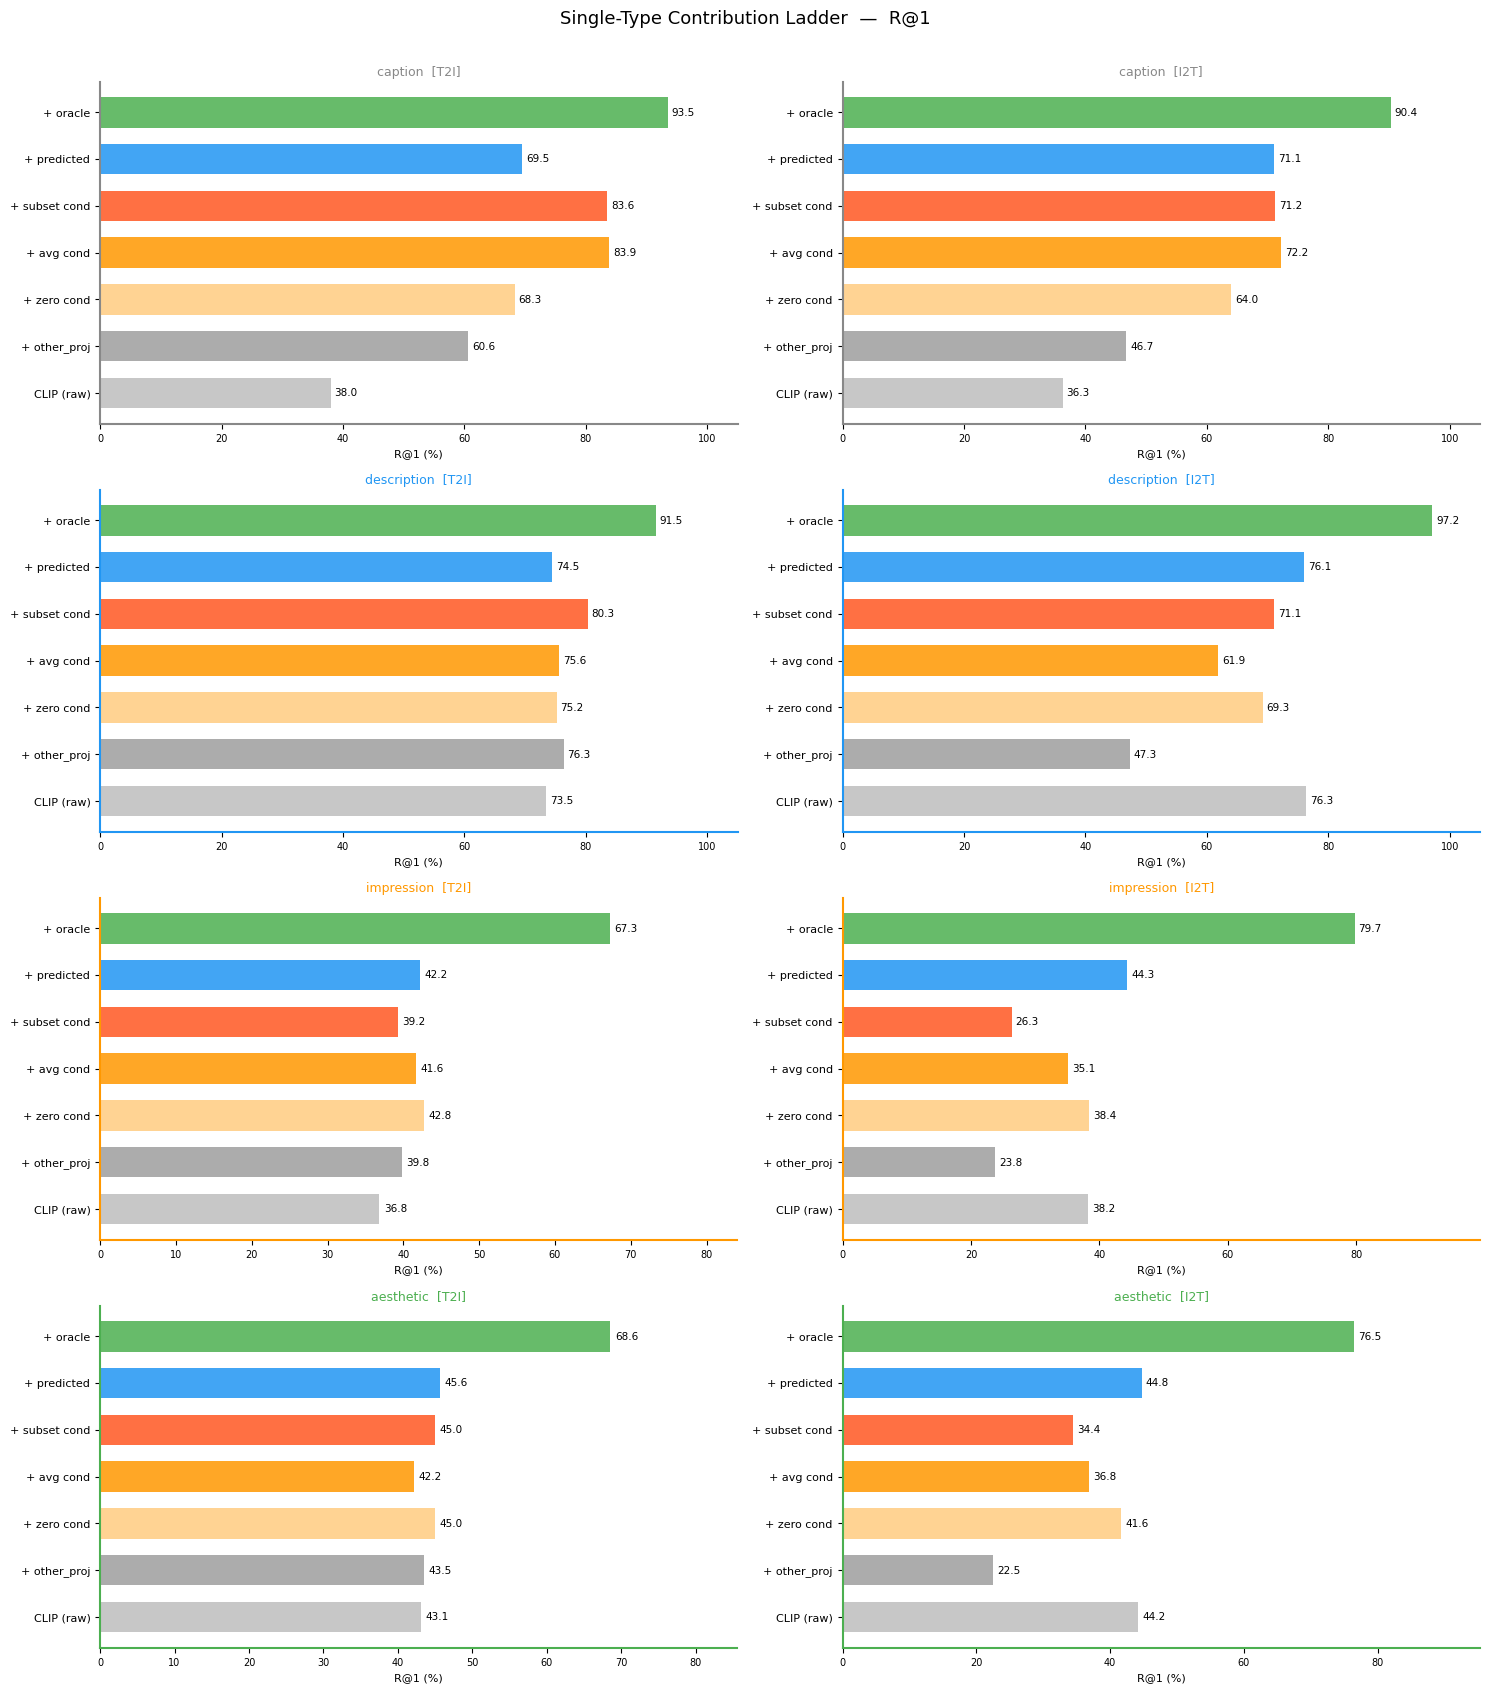


Subset          Side  step                 R@1    R@5    R@10
------------------------------------------------------------
caption          T2I  CLIP (raw)          38.0   67.0    74.8
caption          T2I  + oracle            93.5   98.7    99.3
caption          I2T  CLIP (raw)          36.3   63.5    73.7
caption          I2T  + oracle            90.4   97.9    99.4
description      T2I  CLIP (raw)          73.5   94.3    97.0
description      T2I  + oracle            91.5   99.4    99.9
description      I2T  CLIP (raw)          76.3   95.9    98.2
description      I2T  + oracle            97.2   99.9   100.0
impression       T2I  CLIP (raw)          36.8   63.6    76.3
impression       T2I  + oracle            67.3   87.8    92.4
impression       I2T  CLIP (raw)          38.2   63.9    75.4
impression       I2T  + oracle            79.7   92.8    94.9
aesthetic        T2I  CLIP (raw)          43.1   68.8    77.5
aesthetic        T2I  + oracle            68.6   87.8    91.2
aestheti

In [10]:
single = [(n, t) for n, t in all_subsets if len(t) == 1]
fig, axes = plt.subplots(len(single), 2, figsize=(15, 4.2 * len(single)))

for row, (name, types) in enumerate(single):
    col = TYPE_COLORS[types[0]]
    plot_ladder(axes[row, 0], all_t2i[name], f"{name}  [T2I]", k=1, header_color=col)
    plot_ladder(axes[row, 1], all_i2t[name], f"{name}  [I2T]", k=1, header_color=col)

plt.suptitle("Single-Type Contribution Ladder  —  R@1", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# R@1/5/10 compact table
print(f"\n{'Subset':<14} {'Side':>5}  {'step':<16}  {'R@1':>6} {'R@5':>6} {'R@10':>7}")
print("-" * 60)
for name, types in single:
    for side, ladder in [("T2I", all_t2i[name]), ("I2T", all_i2t[name])]:
        for sname, ranks, _ in [ladder[0], ladder[-1]]:  # CLIP + oracle only
            print(f"{name:<14} {side:>5}  {sname:<16}  "
                  f"{r_at_k(ranks,1):>6.1f} {r_at_k(ranks,5):>6.1f} {r_at_k(ranks,10):>7.1f}")

---
## 2 — Two-Type Combos

All C(4,2)=6 pairs. For I2T, each image has 2 GT texts in the gallery; best-rank used for R@k.

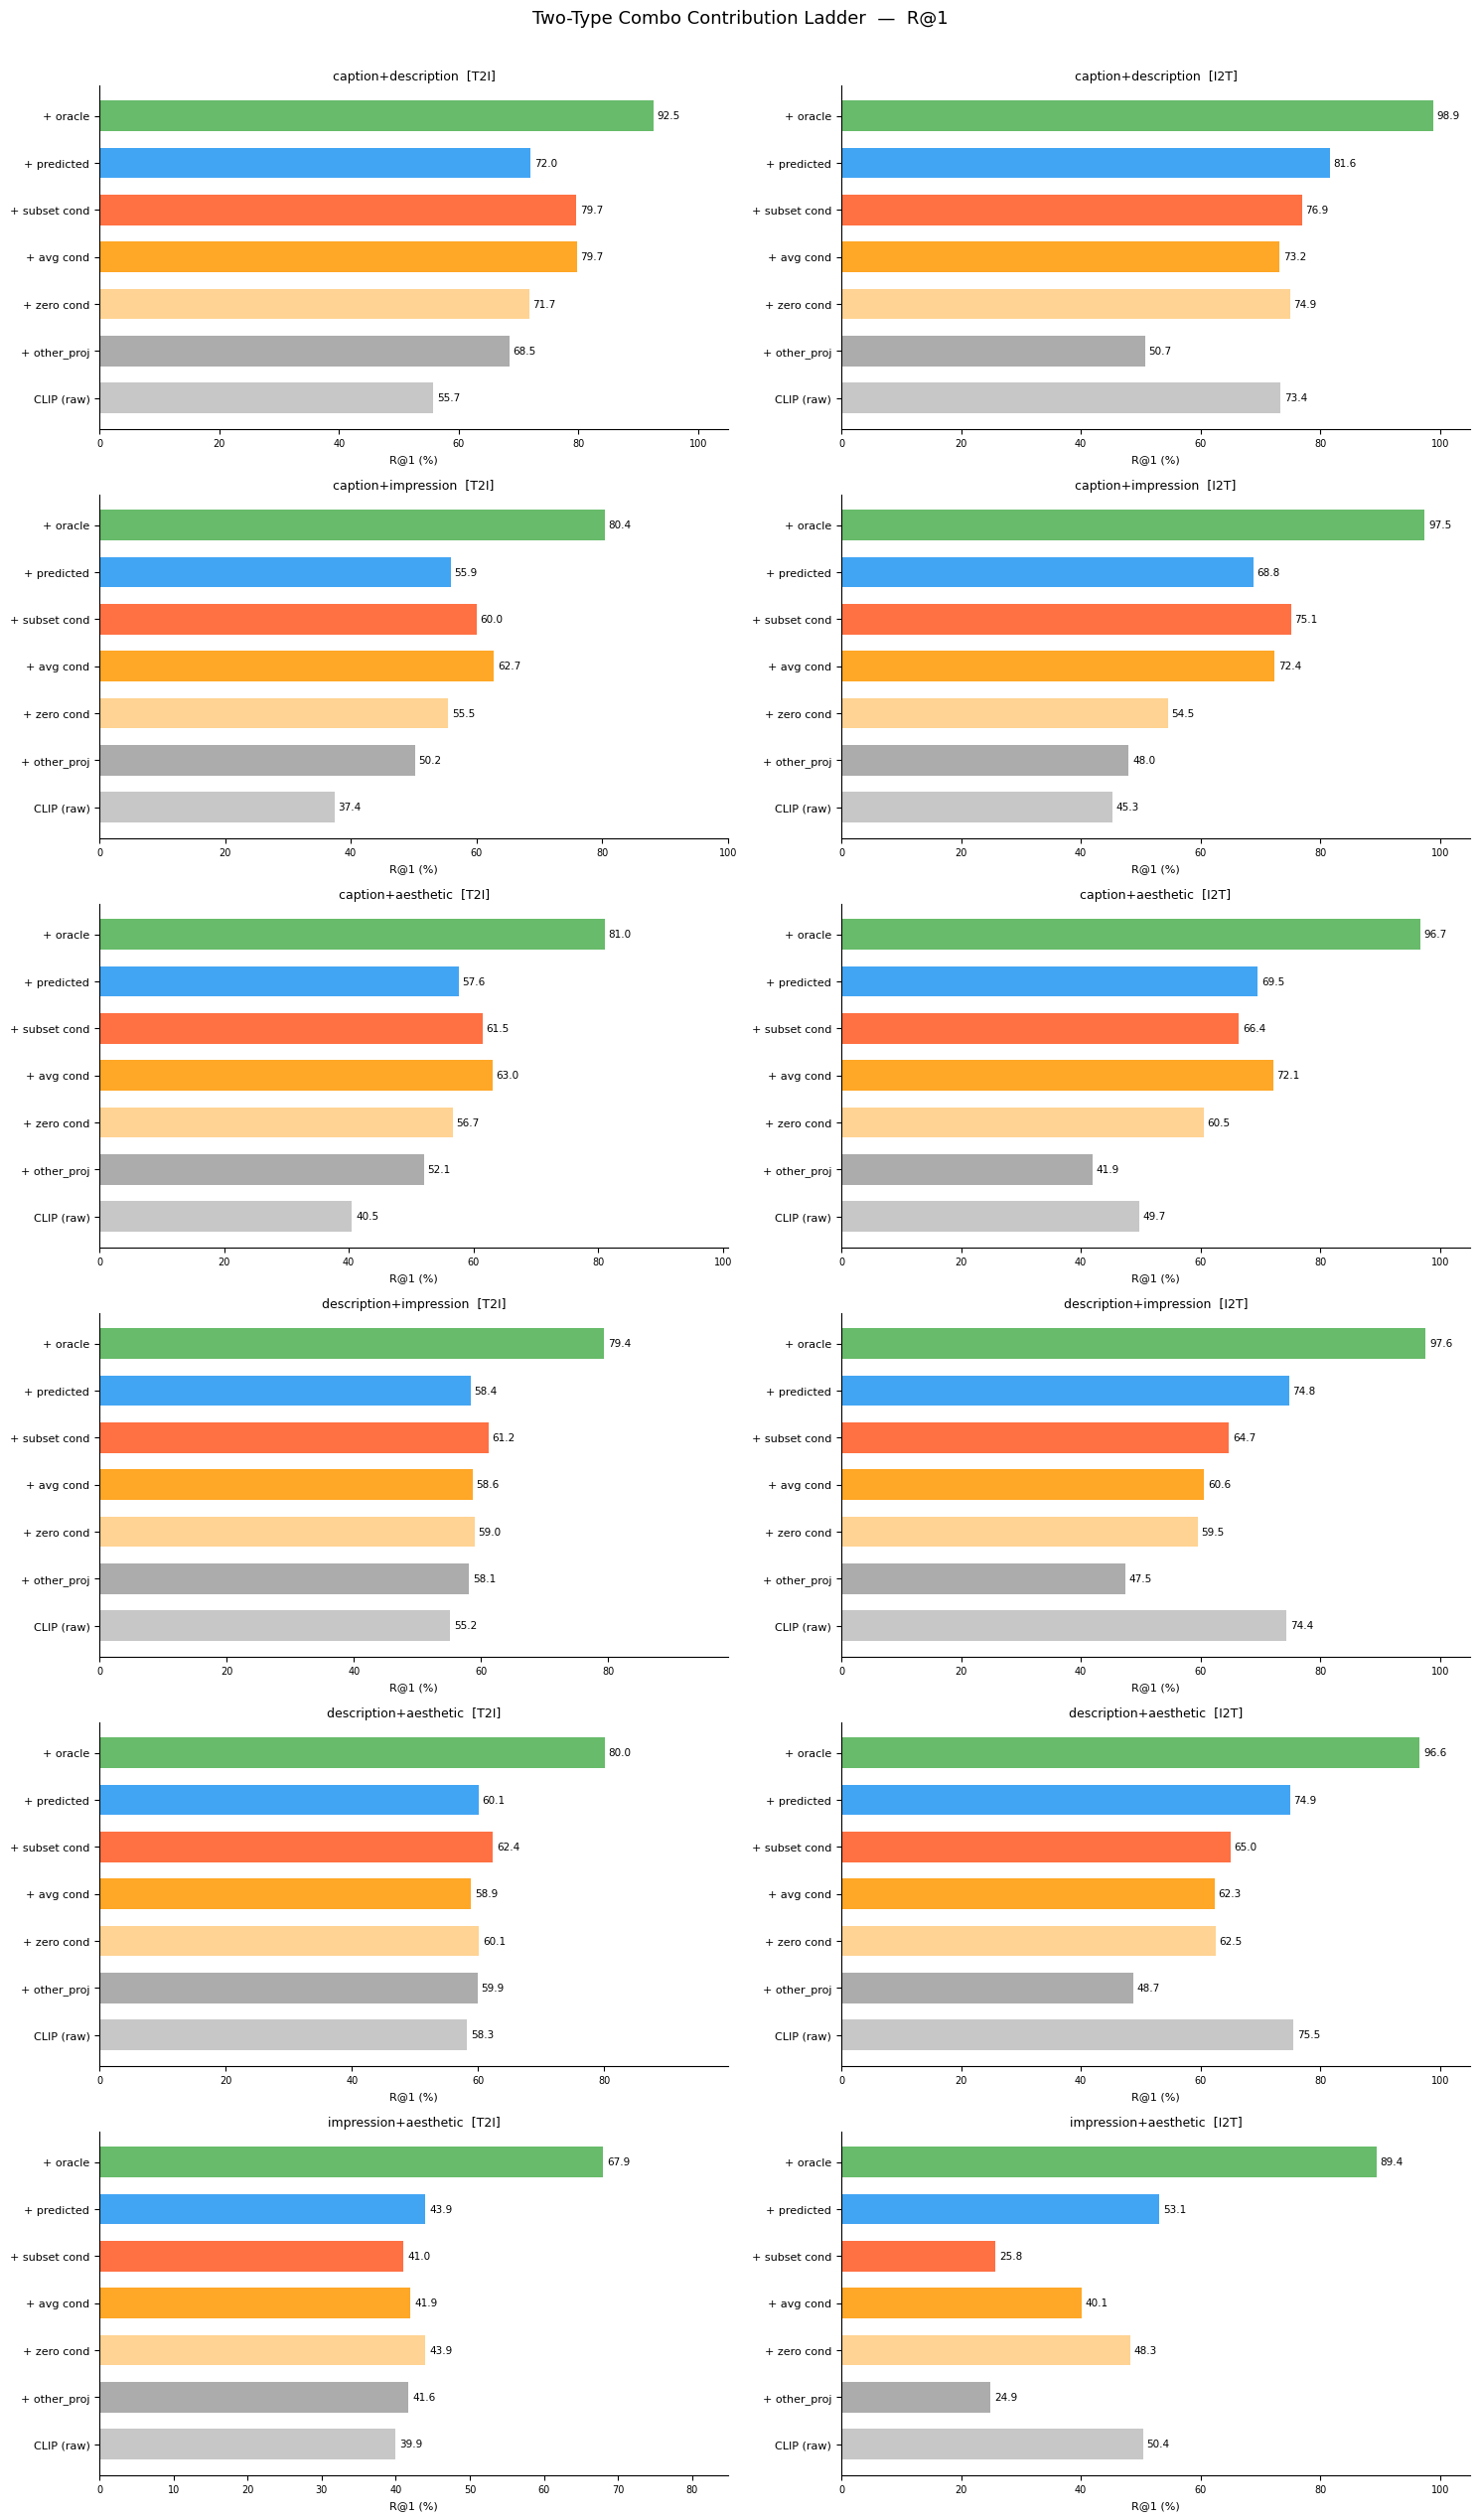


Subset                          Side  step                 R@1    R@5    R@10
-------------------------------------------------------------------------
caption+description              T2I  CLIP (raw)          55.7   80.7    85.9
caption+description              T2I  + oracle            92.5   99.1    99.6
caption+description              I2T  CLIP (raw)          73.4   92.4    95.8
caption+description              I2T  + oracle            98.9   99.7   100.0
caption+impression               T2I  CLIP (raw)          37.4   65.3    75.6
caption+impression               T2I  + oracle            80.4   93.3    95.8
caption+impression               I2T  CLIP (raw)          45.3   72.4    83.1
caption+impression               I2T  + oracle            97.5   99.3    99.3
caption+aesthetic                T2I  CLIP (raw)          40.5   67.9    76.1
caption+aesthetic                T2I  + oracle            81.0   93.3    95.3
caption+aesthetic                I2T  CLIP (raw)          49.7   77

In [11]:
combos2 = [(n, t) for n, t in all_subsets if len(t) == 2]
ncols   = 2  # T2I / I2T
fig, axes = plt.subplots(len(combos2), 2, figsize=(15, 4.2 * len(combos2)))

for row, (name, types) in enumerate(combos2):
    plot_ladder(axes[row, 0], all_t2i[name], f"{name}  [T2I]", k=1)
    plot_ladder(axes[row, 1], all_i2t[name], f"{name}  [I2T]", k=1)

plt.suptitle("Two-Type Combo Contribution Ladder  —  R@1", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

print(f"\n{'Subset':<30} {'Side':>5}  {'step':<16}  {'R@1':>6} {'R@5':>6} {'R@10':>7}")
print("-" * 73)
for name, types in combos2:
    for side, ladder in [("T2I", all_t2i[name]), ("I2T", all_i2t[name])]:
        for sname, ranks, _ in [ladder[0], ladder[-1]]:
            print(f"{name:<30} {side:>5}  {sname:<16}  "
                  f"{r_at_k(ranks,1):>6.1f} {r_at_k(ranks,5):>6.1f} {r_at_k(ranks,10):>7.1f}")

---
## 3 — Three-Type Combos

All C(4,3)=4 triples. For I2T, each image has 3 GT texts in the gallery.

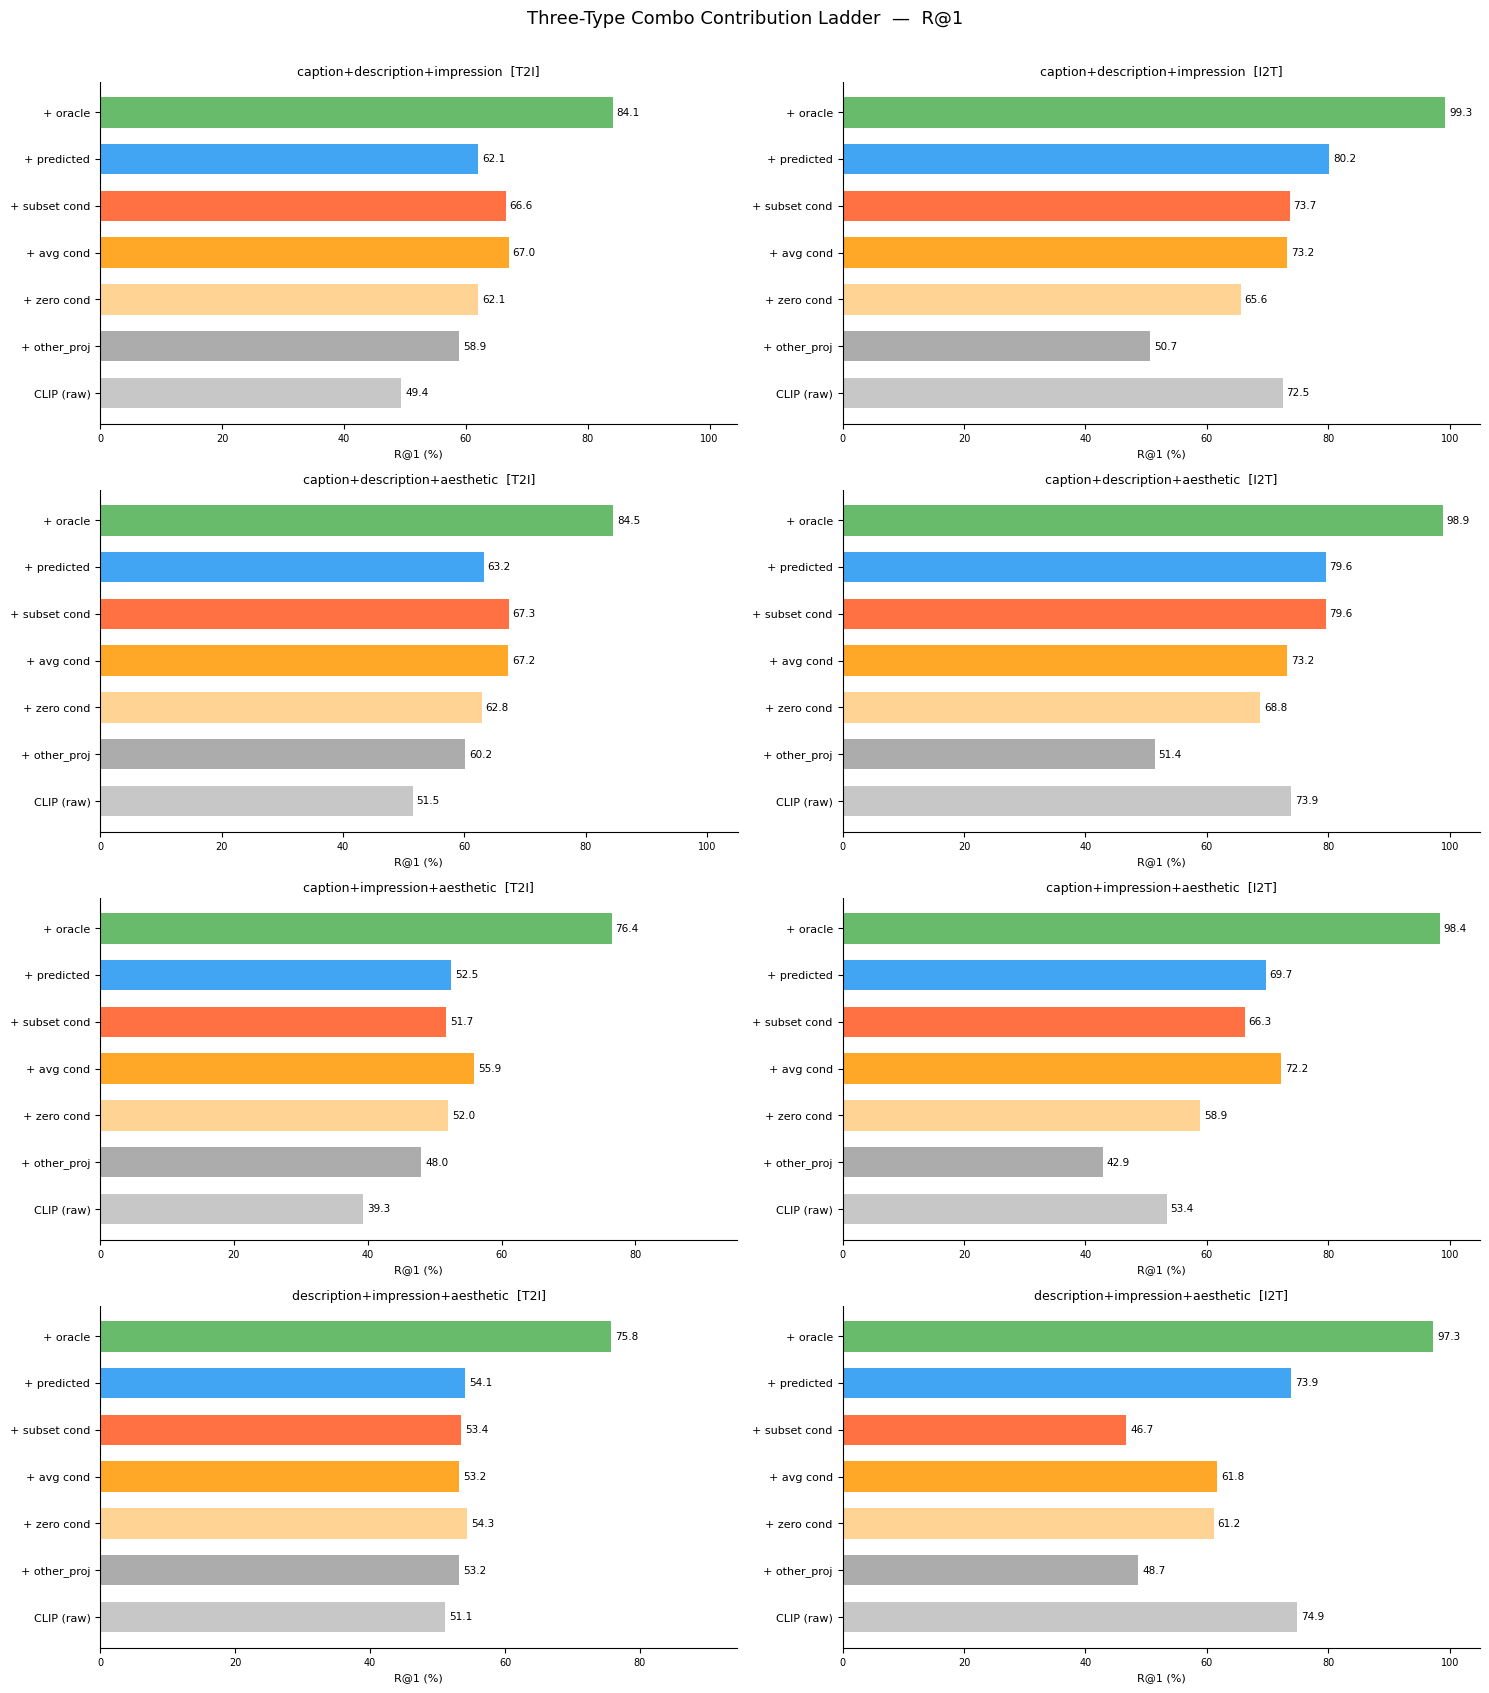


Subset                                    Side  step                 R@1    R@5    R@10
-----------------------------------------------------------------------------------
caption+description+impression             T2I  CLIP (raw)          49.4   75.0    82.7
caption+description+impression             T2I  + oracle            84.1   95.3    97.2
caption+description+impression             I2T  CLIP (raw)          72.5   91.8    95.9
caption+description+impression             I2T  + oracle            99.3   99.7   100.0
caption+description+aesthetic              T2I  CLIP (raw)          51.5   76.7    83.1
caption+description+aesthetic              T2I  + oracle            84.5   95.3    96.8
caption+description+aesthetic              I2T  CLIP (raw)          73.9   93.2    96.6
caption+description+aesthetic              I2T  + oracle            98.9   99.9   100.0
caption+impression+aesthetic               T2I  CLIP (raw)          39.3   66.5    76.2
caption+impression+aesthetic       

In [12]:
combos3 = [(n, t) for n, t in all_subsets if len(t) == 3]
fig, axes = plt.subplots(len(combos3), 2, figsize=(15, 4.2 * len(combos3)))

for row, (name, types) in enumerate(combos3):
    plot_ladder(axes[row, 0], all_t2i[name], f"{name}  [T2I]", k=1)
    plot_ladder(axes[row, 1], all_i2t[name], f"{name}  [I2T]", k=1)

plt.suptitle("Three-Type Combo Contribution Ladder  —  R@1", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

print(f"\n{'Subset':<40} {'Side':>5}  {'step':<16}  {'R@1':>6} {'R@5':>6} {'R@10':>7}")
print("-" * 83)
for name, types in combos3:
    for side, ladder in [("T2I", all_t2i[name]), ("I2T", all_i2t[name])]:
        for sname, ranks, _ in [ladder[0], ladder[-1]]:
            print(f"{name:<40} {side:>5}  {sname:<16}  "
                  f"{r_at_k(ranks,1):>6.1f} {r_at_k(ranks,5):>6.1f} {r_at_k(ranks,10):>7.1f}")

---
## 4 — Summary Heatmaps

R@1 for every pipeline step × every subset, for T2I and I2T.  
Columns ordered: single types → 2-combos → 3-combos → all.  
Colour scale is per-row (each method normalised independently) to highlight *within-method* variance across subsets.

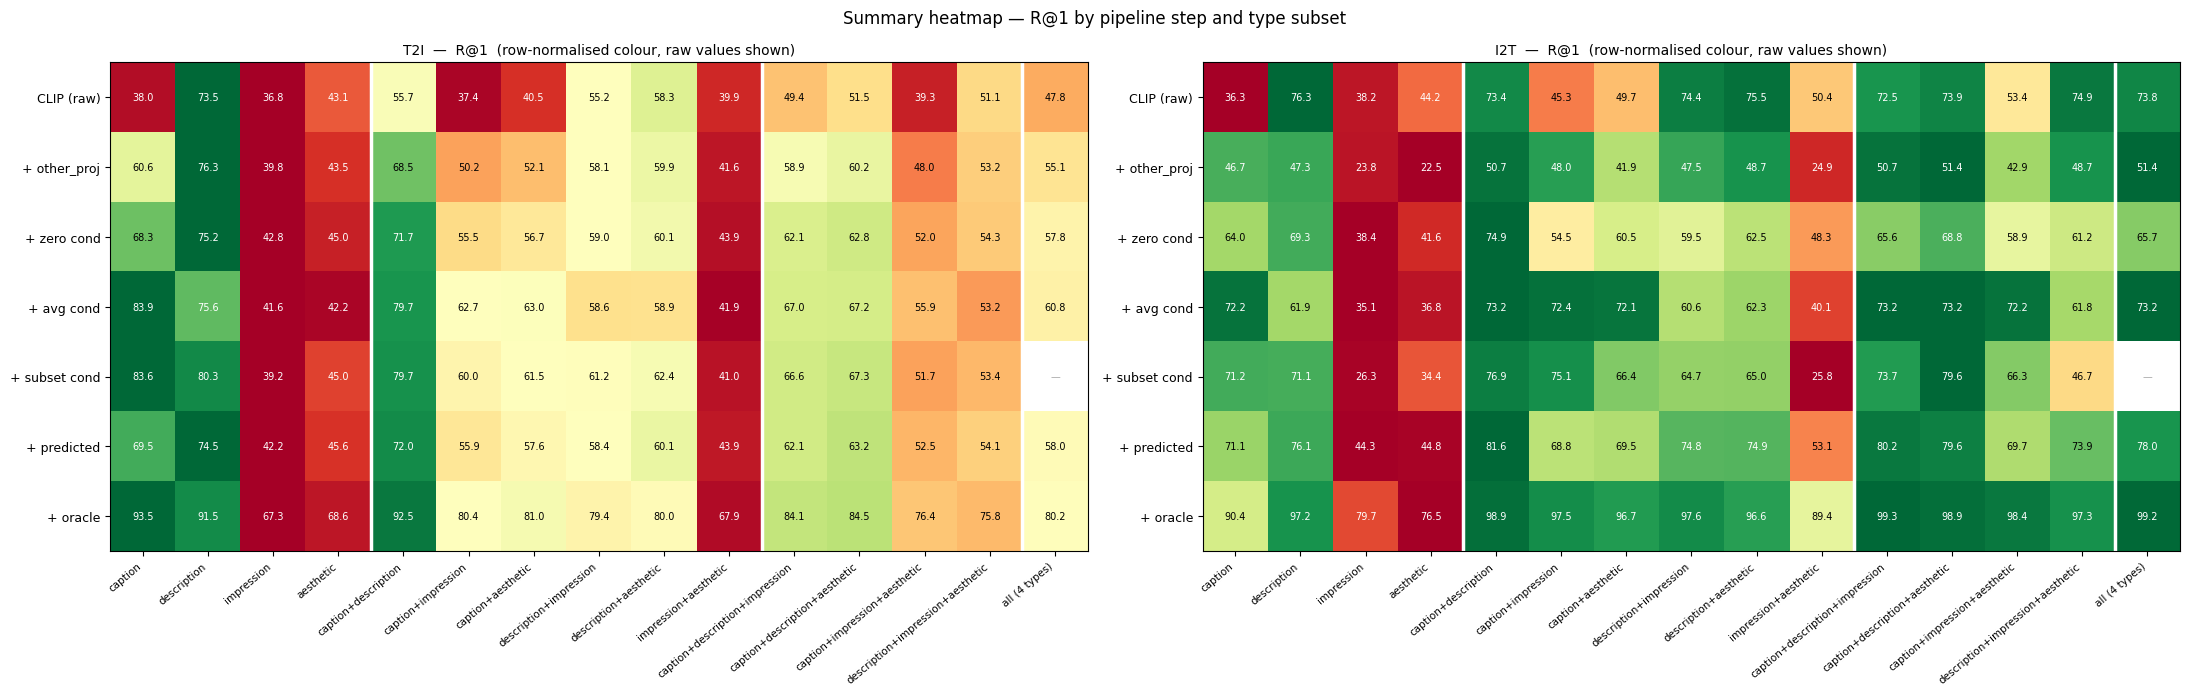

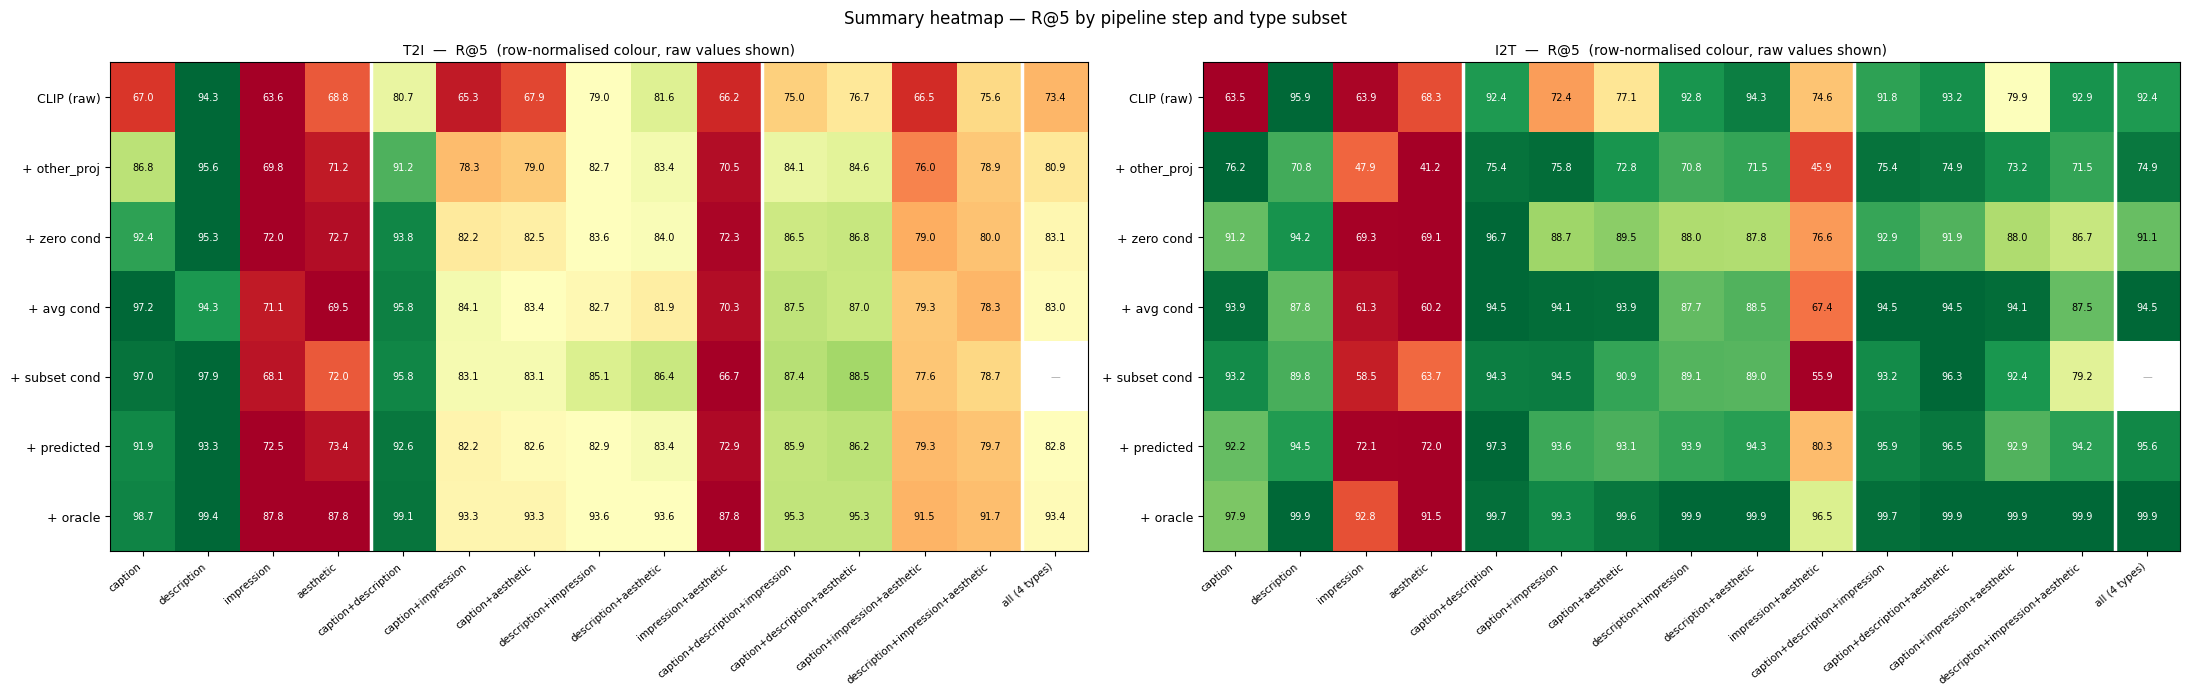

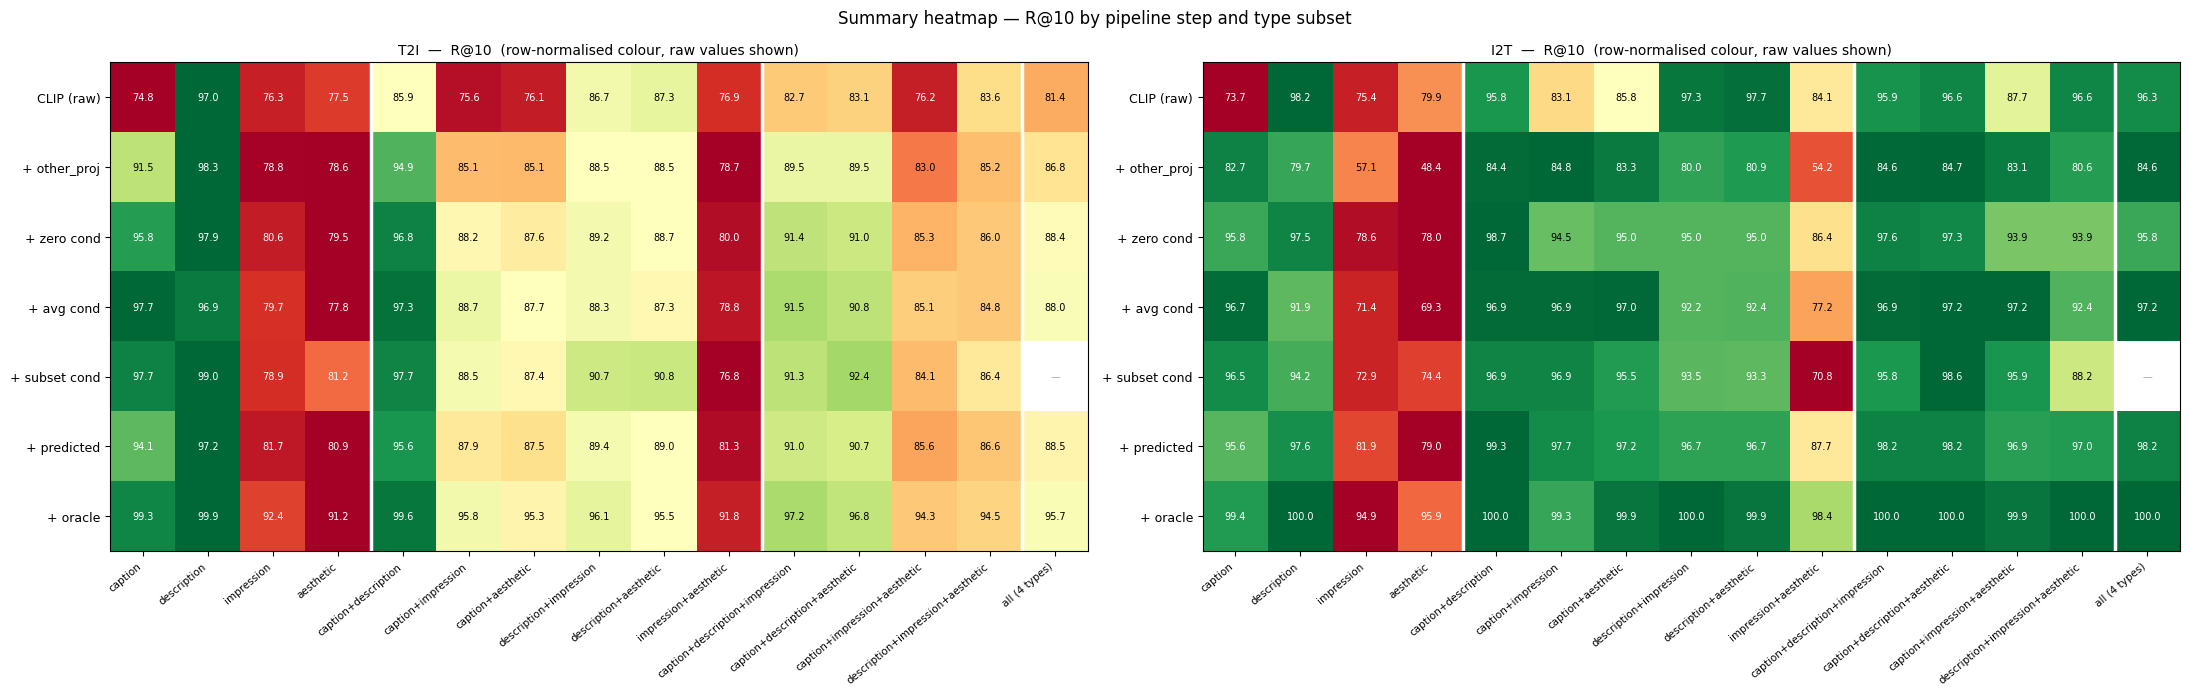

In [13]:
# Canonical step order — covers all steps including subset cond
step_names_all = list(STEP_COLORS.keys())
# Keep only steps that appear in at least one ladder
present = set()
for ld in list(all_t2i.values()) + list(all_i2t.values()):
    present.update(x[0] for x in ld)
step_names   = [s for s in step_names_all if s in present]
subset_names = [n for n, _ in all_subsets]

def build_matrix(ladder_dict, k=1):
    """Build (n_steps, n_subsets) matrix of R@k; NaN if step absent for that subset."""
    mat = np.full((len(step_names), len(subset_names)), np.nan)
    for col, name in enumerate(subset_names):
        name_to_ranks = {x[0]: x[1] for x in ladder_dict[name]}
        for row, sname in enumerate(step_names):
            if sname in name_to_ranks:
                mat[row, col] = r_at_k(name_to_ranks[sname], k)
    return mat

for k in [1, 5, 10]:
    mat_t2i = build_matrix(all_t2i, k)
    mat_i2t = build_matrix(all_i2t, k)

    fig, axes = plt.subplots(1, 2, figsize=(22, 0.65 * len(step_names) + 2.5))

    for ax, mat, side in [(axes[0], mat_t2i, "T2I"), (axes[1], mat_i2t, "I2T")]:
        # Row-normalise so each method's range maps to [0,1]
        row_min = np.nanmin(mat, axis=1, keepdims=True)
        row_max = np.nanmax(mat, axis=1, keepdims=True)
        normed  = (mat - row_min) / np.where(row_max - row_min > 0, row_max - row_min, 1)

        im = ax.imshow(normed, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

        # Annotate cells with actual R@k values
        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                if not np.isnan(mat[r, c]):
                    ax.text(c, r, f"{mat[r,c]:.1f}",
                            ha="center", va="center", fontsize=7,
                            color="black" if 0.2 < normed[r, c] < 0.8 else "white")
                else:
                    ax.text(c, r, "—", ha="center", va="center", fontsize=7, color="#aaa")

        ax.set_xticks(range(len(subset_names)))
        ax.set_xticklabels(subset_names, rotation=40, ha="right", fontsize=7.5)
        ax.set_yticks(range(len(step_names)))
        ax.set_yticklabels(step_names, fontsize=9)

        # Visual separators: single | 2-combo | 3-combo | all
        for sep in [3.5, 9.5, 13.5]:
            ax.axvline(sep, color="white", lw=2.5)

        ax.set_title(f"{side}  —  R@{k}  (row-normalised colour, raw values shown)",
                     fontsize=10)

    plt.suptitle(f"Summary heatmap — R@{k} by pipeline step and type subset", fontsize=12)
    plt.tight_layout()
    plt.show()


---
## 5 — Full Result Tables

All R@1 / R@5 / R@10 numbers for every subset × every step, both sides.

In [14]:
for side, ladder_dict in [("T2I", all_t2i), ("I2T", all_i2t)]:
    print(f"\n{'═'*85}")
    print(f"  {side} — R@1 / R@5 / R@10")
    print(f"{'═'*85}")
    print(f"{'Subset':<35} {'Step':<16}  {'R@1':>6} {'R@5':>6} {'R@10':>7}")
    print("-" * 75)
    for name, types in all_subsets:
        for sname, ranks, _ in ladder_dict[name]:
            print(f"{name:<35} {sname:<16}  "
                  f"{r_at_k(ranks,1):>6.1f} {r_at_k(ranks,5):>6.1f} {r_at_k(ranks,10):>7.1f}")
        print()


═════════════════════════════════════════════════════════════════════════════════════
  T2I — R@1 / R@5 / R@10
═════════════════════════════════════════════════════════════════════════════════════
Subset                              Step                 R@1    R@5    R@10
---------------------------------------------------------------------------
caption                             CLIP (raw)          38.0   67.0    74.8
caption                             + other_proj        60.6   86.8    91.5
caption                             + zero cond         68.3   92.4    95.8
caption                             + avg cond          83.9   97.2    97.7
caption                             + subset cond       83.6   97.0    97.7
caption                             + predicted         69.5   91.9    94.1
caption                             + oracle            93.5   98.7    99.3

description                         CLIP (raw)          73.5   94.3    97.0
description                         + oth

---
## 6 — Automatic Statistical Analysis

Rule-based interpretation of R@1 values — no manual reading required.

| Symbol | Meaning |
|---|---|
| ✓✓ | strong gain ≥ 10 pp |
| ✓  | moderate gain ≥ 5 pp |
| ~  | negligible  (−1.5 … +5 pp) |
| ✗  | hurts  < −1.5 pp |

Thresholds are configurable in `THRESHOLDS` below.  
Analysis is split into four parts: **(A)** per-type marginal gain breakdown, **(B)** component-vs-type grid, **(C)** predictor quality, **(D)** cross-type patterns.


In [15]:
# ── Configurable thresholds ────────────────────────────────────────────────────
THRESHOLDS = dict(
    strong      = 10.0,   # pp gain: "strong"
    moderate    =  5.0,   # pp gain: "moderate"
    negligible  =  1.5,   # |pp| below which we call it negligible
    ceiling     = 88.0,   # CLIP R@1 above which retrieval is near-saturated
    floor       = 55.0,   # CLIP R@1 below which CLIP is struggling
    headroom    = 10.0,   # oracle − predicted gap worth flagging
    asym        = 10.0,   # |T2I oracle − I2T oracle| worth flagging
)

# ── Helpers ────────────────────────────────────────────────────────────────────
def sv(ladder, step, k=1):
    """Single value: R@k for a named step in a ladder, or None."""
    for x in ladder:
        if x[0] == step:
            return r_at_k(x[1], k)
    return None

def marginals(ladder, k=1):
    """Consecutive marginal gains: list of (step_name, delta_pp)."""
    vals = [(x[0], r_at_k(x[1], k)) for x in ladder]
    return [(vals[i][0], vals[i][1] - vals[i-1][1]) for i in range(1, len(vals))]

def symbol(d):
    if d is None:           return "  n/a      "
    if d >= THRESHOLDS["strong"]:   return f"✓✓ strong    ({d:+6.1f}pp)"
    if d >= THRESHOLDS["moderate"]: return f"✓  moderate  ({d:+6.1f}pp)"
    if d > -THRESHOLDS["negligible"]: return f"~  negligible({d:+6.1f}pp)"
    return                           f"✗  HURTS     ({d:+6.1f}pp)"

def best_static_step(ladder):
    """Name of the best deterministic condition step present (subset > avg > zero)."""
    for s in ["+ subset cond", "+ avg cond", "+ zero cond"]:
        if any(x[0] == s for x in ladder):
            return s
    return None

print("Analysis helpers ready.")


Analysis helpers ready.


In [16]:
# ── (A) Per-type marginal gain breakdown ──────────────────────────────────────
# For each single type, print every pipeline step's marginal R@1 gain,
# and synthesise a plain-English conclusion.

k = 1
single = [(n, t) for n, t in all_subsets if len(t) == 1]

print("━" * 70)
print(f"  (A)  PER-TYPE MARGINAL GAIN BREAKDOWN  (R@{k})")
print("━" * 70)

for name, types in single:
    col_t = THRESHOLDS["ceiling"]
    col_f = THRESHOLDS["floor"]

    clip_t = sv(all_t2i[name], "CLIP (raw)", k)
    clip_i = sv(all_i2t[name], "CLIP (raw)", k)
    oracle_t = sv(all_t2i[name], "+ oracle", k)
    oracle_i = sv(all_i2t[name], "+ oracle", k)

    print(f"\n▸ {name.upper()}")
    print(f"  CLIP R@1  →  T2I {clip_t:.1f}%   I2T {clip_i:.1f}%")

    # Baseline diagnosis
    if clip_t >= col_t:
        print(f"  ⚑ T2I CLIP near-ceiling ({clip_t:.1f}% ≥ {col_t}%) — pipeline adds little headroom")
    elif clip_t < col_f:
        print(f"  ⚑ T2I CLIP struggling ({clip_t:.1f}% < {col_f}%) — pipeline is critical for this type")
    else:
        print(f"  ⚑ T2I CLIP moderate ({clip_t:.1f}%) — meaningful room for improvement")

    # Marginal gain table
    print(f"  {'Step':<16}   T2I                    I2T")
    print(f"  {'-'*16}   {'─'*26}  {'─'*26}")
    t2i_mg = {s: d for s, d in marginals(all_t2i[name], k)}
    i2t_mg = {s: d for s, d in marginals(all_i2t[name], k)}
    all_steps = list(dict.fromkeys(list(t2i_mg) + list(i2t_mg)))  # union, ordered
    for step in all_steps:
        dt = t2i_mg.get(step)
        di = i2t_mg.get(step)
        print(f"  {step:<16}   {symbol(dt)}   {symbol(di)}")

    # Largest single gain
    if t2i_mg:
        best_step_t = max(t2i_mg, key=t2i_mg.get)
        print(f"  → Biggest T2I lift: '{best_step_t}' ({t2i_mg[best_step_t]:+.1f}pp)")
    # Any regressions?
    bad_t = [s for s, d in t2i_mg.items() if d < -THRESHOLDS["negligible"]]
    if bad_t:
        print(f"  ⚠ T2I regression(s): {bad_t}")
    bad_i = [s for s, d in i2t_mg.items() if d < -THRESHOLDS["negligible"]]
    if bad_i:
        print(f"  ⚠ I2T regression(s): {bad_i}")

    # Total pipeline gain
    if oracle_t is not None and clip_t is not None:
        total_t = oracle_t - clip_t
        total_i = oracle_i - clip_i if oracle_i and clip_i else None
        verdict_t = ("strong improvement" if total_t >= THRESHOLDS["strong"]
                     else "moderate improvement" if total_t >= THRESHOLDS["moderate"]
                     else "negligible improvement")
        print(f"  → Total pipeline gain: T2I +{total_t:.1f}pp ({verdict_t})"
              + (f",  I2T +{total_i:.1f}pp" if total_i is not None else ""))

    # T2I / I2T asymmetry at oracle level
    if oracle_t is not None and oracle_i is not None:
        asym = oracle_t - oracle_i
        if abs(asym) >= THRESHOLDS["asym"]:
            harder = "T2I harder (text queries less discriminative)" if asym < 0 \
                     else "I2T harder (image queries less discriminative)"
            print(f"  → T2I/I2T oracle: {oracle_t:.1f}% vs {oracle_i:.1f}%  ⇒ {harder}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  (A)  PER-TYPE MARGINAL GAIN BREAKDOWN  (R@1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ CAPTION
  CLIP R@1  →  T2I 38.0%   I2T 36.3%
  ⚑ T2I CLIP struggling (38.0% < 55.0%) — pipeline is critical for this type
  Step               T2I                    I2T
  ----------------   ──────────────────────────  ──────────────────────────
  + other_proj       ✓✓ strong    ( +22.7pp)   ✓✓ strong    ( +10.5pp)
  + zero cond        ✓  moderate  (  +7.6pp)   ✓✓ strong    ( +17.3pp)
  + avg cond         ✓✓ strong    ( +15.6pp)   ✓  moderate  (  +8.2pp)
  + subset cond      ~  negligible(  -0.3pp)   ~  negligible(  -1.0pp)
  + predicted        ✗  HURTS     ( -14.0pp)   ~  negligible(  -0.1pp)
  + oracle           ✓✓ strong    ( +23.9pp)   ✓✓ strong    ( +19.3pp)
  → Biggest T2I lift: '+ oracle' (+23.9pp)
  ⚠ T2I regression(s): ['+ predicted']
  → Total pipeline gain: T2I +55.5pp (strong improveme

In [17]:
# ── (B) Component-vs-type effectiveness grid ──────────────────────────────────
# One row per pipeline step, one column per single type.
# Values show the marginal T2I R@1 gain for that step × type combo.
# Makes it easy to see which component "owns" which type.

k = 1
single = [(n, t) for n, t in all_subsets if len(t) == 1]
type_names_short = [n for n, _ in single]

# Collect all step names present across single-type T2I ladders (preserve order)
seen = {}
for name, _ in single:
    for step, d in marginals(all_t2i[name], k):
        seen[step] = True
steps_ordered = list(seen.keys())

print("━" * 70)
print(f"  (B)  COMPONENT × TYPE EFFECTIVENESS GRID  (T2I marginal R@1, R@{k})")
print("━" * 70)
print()

# Header
col_w = 13
print(f"  {'Step':<18}", end="")
for n in type_names_short:
    print(f"  {n:>{col_w}}", end="")
print()
print("  " + "─" * (18 + (col_w + 2) * len(type_names_short)))

for step in steps_ordered:
    print(f"  {step:<18}", end="")
    step_vals = []
    for name, _ in single:
        mg = dict(marginals(all_t2i[name], k))
        d  = mg.get(step)
        step_vals.append(d)
        if d is None:
            cell = f"{'—':>{col_w}}"
        else:
            s = "✓✓" if d >= THRESHOLDS["strong"] else ("✓" if d >= THRESHOLDS["moderate"] else ("✗" if d < -THRESHOLDS["negligible"] else "~"))
            cell = f"{s} {d:+5.1f}pp"
            cell = f"{cell:>{col_w}}"
        print(f"  {cell}", end="")
    # Which type benefits most from this step?
    valid = [(type_names_short[i], v) for i, v in enumerate(step_vals) if v is not None]
    if valid:
        best_type, best_val = max(valid, key=lambda x: x[1])
        worst_type, worst_val = min(valid, key=lambda x: x[1])
        print(f"   ← best: {best_type} ({best_val:+.1f}pp)", end="")
        if worst_val < -THRESHOLDS["negligible"]:
            print(f"  worst: {worst_type} ({worst_val:+.1f}pp)", end="")
    print()

print()
print("  Legend: ✓✓ strong ≥10pp  |  ✓ moderate ≥5pp  |  ~ negligible  |  ✗ hurts")

# Synthesise: which step dominates each type?
print()
print("  ── Dominant step per type (T2I) ──────────────────────────────────────")
for name, _ in single:
    mg = dict(marginals(all_t2i[name], k))
    if not mg:
        continue
    best_step = max(mg, key=mg.get)
    best_val  = mg[best_step]
    verdict   = symbol(best_val)
    print(f"  {name:<14}: '{best_step}' dominates  {verdict}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  (B)  COMPONENT × TYPE EFFECTIVENESS GRID  (T2I marginal R@1, R@1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Step                      caption    description     impression      aesthetic
  ──────────────────────────────────────────────────────────────────────────────
  + other_proj           ✓✓ +22.7pp      ~  +2.8pp      ~  +3.0pp      ~  +0.4pp   ← best: caption (+22.7pp)
  + zero cond             ✓  +7.6pp      ~  -1.1pp      ~  +3.0pp      ~  +1.6pp   ← best: caption (+7.6pp)
  + avg cond             ✓✓ +15.6pp      ~  +0.4pp      ~  -1.1pp      ✗  -2.8pp   ← best: caption (+15.6pp)  worst: aesthetic (-2.8pp)
  + subset cond           ~  -0.3pp      ~  +4.7pp      ✗  -2.4pp      ~  +2.8pp   ← best: description (+4.7pp)  worst: impression (-2.4pp)
  + predicted             ✗ -14.0pp      ✗  -5.8pp      ~  +3.0pp      ~  +0.6pp   ← best: impression (+3.0pp)  worst: caption (-14.0p

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  (C)  PREDICTOR QUALITY  (T2I R@1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Type           best_static  predicted   oracle  pred−static  oracle−pred  interpretation
  ───────────────────────────────────────────────────────────────────────────────────────────────
  caption              83.6%      69.5%    93.5%       -14.0pp       +23.9pp  predictor UNDERPERFORMS static cond ✗; headroom 23.9pp — room to improve
  description          80.3%      74.5%    91.5%        -5.8pp       +17.0pp  predictor UNDERPERFORMS static cond ✗; headroom 17.0pp — room to improve
  impression           39.2%      42.2%    67.3%        +3.0pp       +25.1pp  predictor ≈ static cond (no per-instance gain); headroom 25.1pp — room to improve
  aesthetic            45.0%      45.6%    68.6%        +0.6pp       +22.9pp  predictor ≈ static cond (no per-instance gain); headroom 22.9pp — room to improve


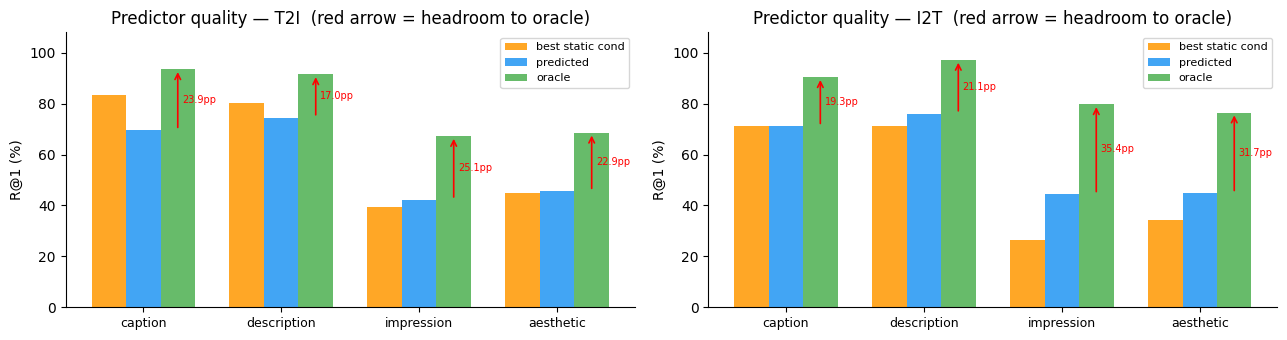

In [18]:
# ── (C) Predictor quality analysis ────────────────────────────────────────────
# Three questions per type:
#   1. Does the predictor beat the best static condition? (per-instance value)
#   2. How far is the predictor from oracle? (headroom)
#   3. Subset-specific vs avg condition: does type specialisation help?

k = 1
single = [(n, t) for n, t in all_subsets if len(t) == 1]

print("━" * 70)
print(f"  (C)  PREDICTOR QUALITY  (T2I R@{k})")
print("━" * 70)
print()
print(f"  {'Type':<14} {'best_static':>11} {'predicted':>10} {'oracle':>8}"
      f" {'pred−static':>12} {'oracle−pred':>12}  interpretation")
print("  " + "─" * 95)

for name, _ in single:
    ld = all_t2i[name]
    best_s_name = best_static_step(ld)
    v_static    = sv(ld, best_s_name,  k) if best_s_name else None
    v_pred      = sv(ld, "+ predicted",  k)
    v_oracle    = sv(ld, "+ oracle",     k)

    gain_pred   = (v_pred - v_static)   if (v_pred  is not None and v_static  is not None) else None
    headroom    = (v_oracle - v_pred)   if (v_oracle is not None and v_pred    is not None) else None

    # Interpretation
    parts = []
    if gain_pred is not None:
        if gain_pred >= THRESHOLDS["moderate"]:
            parts.append("predictor adds per-instance value ✓")
        elif gain_pred < -THRESHOLDS["negligible"]:
            parts.append("predictor UNDERPERFORMS static cond ✗")
        else:
            parts.append("predictor ≈ static cond (no per-instance gain)")
    if headroom is not None:
        if headroom >= THRESHOLDS["headroom"]:
            parts.append(f"headroom {headroom:.1f}pp — room to improve")
        elif headroom < THRESHOLDS["negligible"]:
            parts.append("predictor near-oracle — well-trained")

    print(f"  {name:<14} "
          f"  {v_static:>8.1f}%"   if v_static  is not None else f"  {'n/a':>9}",
          end="")
    print(f"  {v_pred:>8.1f}%"    if v_pred    is not None else f"  {'n/a':>9}",
          end="")
    print(f"  {v_oracle:>6.1f}%"  if v_oracle  is not None else f"  {'n/a':>7}",
          end="")
    print(f"  {gain_pred:>+10.1f}pp" if gain_pred is not None else f"  {'n/a':>11}",
          end="")
    print(f"  {headroom:>+10.1f}pp"  if headroom  is not None else f"  {'n/a':>11}",
          end="")
    print(f"  {'; '.join(parts)}")

# Visualise predictor headroom as bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
type_labels = [n for n, _ in single]

for ax, (side_name, ladder_dict) in zip(axes, [("T2I", all_t2i), ("I2T", all_i2t)]):
    static_vals, pred_vals, oracle_vals = [], [], []
    for name, _ in single:
        ld = ladder_dict[name]
        bs = best_static_step(ld)
        static_vals.append(sv(ld, bs,            k) or 0)
        pred_vals.append(  sv(ld, "+ predicted", k) or 0)
        oracle_vals.append(sv(ld, "+ oracle",     k) or 0)

    x = np.arange(len(type_labels))
    w = 0.25
    ax.bar(x - w, static_vals,  width=w, label="best static cond", color="#FF9800", alpha=0.85)
    ax.bar(x,     pred_vals,    width=w, label="predicted",         color="#2196F3", alpha=0.85)
    ax.bar(x + w, oracle_vals,  width=w, label="oracle",            color="#4CAF50", alpha=0.85)

    # Annotate headroom arrows
    for i, (p, o) in enumerate(zip(pred_vals, oracle_vals)):
        if o - p >= THRESHOLDS["negligible"]:
            ax.annotate("", xy=(x[i]+w, o), xytext=(x[i]+w, p),
                        arrowprops=dict(arrowstyle="->", color="red", lw=1.2))
            ax.text(x[i]+w+0.03, (p+o)/2, f"{o-p:.1f}pp",
                    fontsize=7, color="red", va="center")

    ax.set_xticks(x)
    ax.set_xticklabels(type_labels, fontsize=9)
    ax.set_ylabel(f"R@{k} (%)")
    ax.set_title(f"Predictor quality — {side_name}  (red arrow = headroom to oracle)")
    ax.legend(fontsize=8)
    ax.set_ylim(0, min(max(oracle_vals) * 1.15 + 3, 108))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [19]:
# ── (D) Cross-type patterns ────────────────────────────────────────────────────
# Questions:
#   1. T2I consistency: does combo R@1 ≈ average of its parts? (sanity check —
#      since conditions are image-side, it should hold; deviations reveal edge effects)
#   2. I2T multi-GT benefit: how much does having more GT texts in gallery help?
#   3. Which pair of types is "most compatible" (combo improves over both) vs
#      "most antagonistic" (combo hurts both) — T2I side.

k = 1
single_vals_t2i_oracle = {n: sv(all_t2i[n], "+ oracle", k) for n, _ in all_subsets if len(_) == 1}
single_vals_i2t_oracle = {n: sv(all_i2t[n], "+ oracle", k) for n, _ in all_subsets if len(_) == 1}
single_vals_t2i_clip   = {n: sv(all_t2i[n], "CLIP (raw)", k) for n, _ in all_subsets if len(_) == 1}
single_vals_i2t_clip   = {n: sv(all_i2t[n], "CLIP (raw)", k) for n, _ in all_subsets if len(_) == 1}

combos2 = [(n, t) for n, t in all_subsets if len(t) == 2]
combos3 = [(n, t) for n, t in all_subsets if len(t) == 3]

print("━" * 70)
print(f"  (D)  CROSS-TYPE PATTERNS  (R@{k})")
print("━" * 70)

# ── D1: T2I consistency check ──────────────────────────────────────────────────
print(f"\n  D1 — T2I oracle: combo vs expected average of parts")
print(f"  (Should be ≈ 0 since the combiner is image-side; large deviation = surprising)")
print(f"\n  {'Combo':<32}  {'combo':>7}  {'expected':>9}  {'Δ':>6}  verdict")
print("  " + "─" * 65)

for name, types in combos2:
    combo_v   = sv(all_t2i[name], "+ oracle", k)
    parts_v   = [single_vals_t2i_oracle.get(TYPE_NAMES[t]) for t in types]
    parts_v   = [v for v in parts_v if v is not None]
    expected  = np.mean(parts_v) if parts_v else None
    if combo_v is None or expected is None:
        continue
    delta = combo_v - expected
    verdict = ("surprising synergy !" if delta > THRESHOLDS["moderate"]
               else "surprising conflict !" if delta < -THRESHOLDS["moderate"]
               else "consistent with average")
    print(f"  {name:<32}  {combo_v:>6.1f}%  {expected:>8.1f}%  {delta:>+5.1f}pp  {verdict}")

# ── D2: I2T multi-GT benefit ───────────────────────────────────────────────────
print(f"\n  D2 — I2T oracle: multi-GT benefit from combining types")
print(f"  (Each image has more GT texts in gallery → recall should rise)")
print(f"\n  {'Combo':<32}  {'combo':>7}  {'best_single':>12}  {'gain_over_best':>15}  verdict")
print("  " + "─" * 75)

for name, types in combos2 + combos3:
    combo_v   = sv(all_i2t[name], "+ oracle", k)
    parts_v   = [single_vals_i2t_oracle.get(TYPE_NAMES[t]) for t in types]
    parts_v   = [v for v in parts_v if v is not None]
    best_ind  = max(parts_v) if parts_v else None
    if combo_v is None or best_ind is None:
        continue
    gain = combo_v - best_ind
    verdict = ("strong multi-GT boost ✓✓" if gain >= THRESHOLDS["strong"]
               else "moderate multi-GT boost ✓" if gain >= THRESHOLDS["moderate"]
               else "marginal multi-GT benefit ~" if gain >= THRESHOLDS["negligible"]
               else "no benefit / hurts ✗")
    print(f"  {name:<32}  {combo_v:>6.1f}%  {best_ind:>11.1f}%  {gain:>+14.1f}pp  {verdict}")

# ── D3: Type compatibility ranking ────────────────────────────────────────────
print(f"\n  D3 — 2-type T2I CLIP: which pairs are most / least compatible?")
print(f"  (combo CLIP R@1 vs average of parts — reveals CLIP embedding proximity effects)")
print(f"\n  {'Combo':<32}  {'combo':>7}  {'avg_parts':>10}  {'Δ':>6}")
print("  " + "─" * 58)

pair_deltas = []
for name, types in combos2:
    combo_v  = sv(all_t2i[name], "CLIP (raw)", k)
    parts_v  = [single_vals_t2i_clip.get(TYPE_NAMES[t]) for t in types]
    parts_v  = [v for v in parts_v if v is not None]
    expected = np.mean(parts_v) if parts_v else None
    if combo_v is None or expected is None:
        continue
    delta = combo_v - expected
    pair_deltas.append((name, combo_v, expected, delta))
    print(f"  {name:<32}  {combo_v:>6.1f}%  {expected:>9.1f}%  {delta:>+5.1f}pp")

if pair_deltas:
    best_pair  = max(pair_deltas, key=lambda x: x[3])
    worst_pair = min(pair_deltas, key=lambda x: x[3])
    print(f"\n  → Most compatible pair (CLIP):   {best_pair[0]}  ({best_pair[3]:+.1f}pp)")
    print(f"  → Least compatible pair (CLIP): {worst_pair[0]}  ({worst_pair[3]:+.1f}pp)")

# ── D4: Type-difficulty ranking ────────────────────────────────────────────────
print(f"\n  D4 — Type difficulty ranking (T2I CLIP R@{k}, ascending = harder)")
difficulty = [(n, single_vals_t2i_clip[n]) for n, _ in all_subsets if len(_) == 1
              and single_vals_t2i_clip.get(n) is not None]
difficulty.sort(key=lambda x: x[1])
for rank_i, (n, v) in enumerate(difficulty, 1):
    label = ("hardest" if rank_i == 1
             else "easiest" if rank_i == len(difficulty) else "")
    print(f"  #{rank_i}  {n:<14}  CLIP R@1={v:.1f}%  {label}")

pipeline_gain = [(n, sv(all_t2i[n], "+ oracle", k) - single_vals_t2i_clip[n])
                 for n, _ in all_subsets if len(_) == 1
                 and single_vals_t2i_clip.get(n) is not None
                 and sv(all_t2i[n], "+ oracle", k) is not None]
pipeline_gain.sort(key=lambda x: -x[1])
print(f"\n  D5 — Types that benefit MOST from the full pipeline (T2I oracle − CLIP R@{k})")
for n, gain in pipeline_gain:
    bar = "█" * int(gain / 2)
    print(f"  {n:<14}  +{gain:.1f}pp  {bar}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  (D)  CROSS-TYPE PATTERNS  (R@1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  D1 — T2I oracle: combo vs expected average of parts
  (Should be ≈ 0 since the combiner is image-side; large deviation = surprising)

  Combo                               combo   expected       Δ  verdict
  ─────────────────────────────────────────────────────────────────
  caption+description                 92.5%      92.5%   +0.0pp  consistent with average
  caption+impression                  80.4%      80.4%   +0.0pp  consistent with average
  caption+aesthetic                   81.0%      81.0%   +0.0pp  consistent with average
  description+impression              79.4%      79.4%   +0.0pp  consistent with average
  description+aesthetic               80.0%      80.0%   +0.0pp  consistent with average
  impression+aesthetic                67.9%      67.9%   +0.0pp  consistent with average

  D2 — I2T o